In [4]:
# ! pip install import-ipynb

In [5]:
# !pip show import-ipynb

In [6]:
### This panel goes as a sperate file scrape_nse_new.py  ###
#########################################################################################
# NSE Stock/Indices Scrapper
# Source: https://github.com/alloc7260/NSE
#########################################################################################
import math
import requests
import datetime
import json
import urllib
import pandas as pd
import concurrent
from concurrent.futures import ALL_COMPLETED
# import logging
import nselib
from nselib import capital_market 
#from datetime import datetime, timedelta
import Stock_Analysis as SA



def fetch_quote(sname, start_date, end_date):
    # print("fetching - " + sname + " from " + start_date + " to " + end_date)
    # df = capital_market.price_volume_data(symbol=sname, from_date=start_date, to_date=end_date )
    df = capital_market.price_volume_data(symbol=sname, period="1Y" )
    # print("fetched - ")
    # print(df.head())
    return df

def scrape_data(start_date, end_date, name=None, input_type='stock'):

    start_date = datetime.datetime.strptime(start_date, "%d-%m-%Y")
    end_date = datetime.datetime.strptime(end_date, "%d-%m-%Y")

    # parts = name.split(sep="-")
    # sname = parts[0]
    # result = fetch_quote(name, start_date.strftime('%d-%m-%Y'), end_date.strftime('%d-%m-%Y'))
    result = fetch_quote(name, start_date.strftime('%d-%m-%Y'), end_date.strftime('%d-%m-%Y'))    
    
    # with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
    #     future_to_sname = {executor.submit(fetch_quote, sname=sname
    #                                        ,start_date = start_date.strftime('%d-%m-%Y')
    #                                        , end_date=end_date.strftime('%d-%m-%Y')): sname for sname in [sname]}
    #     concurrent.futures.wait(future_to_sname, return_when=ALL_COMPLETED)
    #     for future in concurrent.futures.as_completed(future_to_sname):
    #         url = future_to_sname[future]
    #         try:
    #             df = future.result()
    #             result = df
    #         except Exception as exc:
    #             # logging.error('%r generated an exception: %s. Please try again later.' % (url, exc))
    #             raise exc
    return format_dataframe_result(result, start_date, end_date)


def format_dataframe_result(result, start_date, end_date):
    if result.empty:
        return f"No Data Found : for date range {start_date} to {end_date}"

    
    result.columns = ['symbol','Series', 'date','PrevClose','open','high','low','LastPrice','close','AveragePrice','volume','TurnOver','No.Trades']
    result.replace(',', '', regex=True, inplace=True)
    result.astype({'PrevClose': 'float', 'open': 'float', 'high': 'float', 'low': 'float', 'LastPrice': 'float', 'close': 'float', 'AveragePrice': 'float', 'volume': 'int', 'TurnOver': 'float', 'No.Trades': 'int'})
    # result['52WH'] = result['close'].max()
    # result['52WL'] = result['close'].min()    
    # result.astype({'52WH': 'float', '52WL': 'float'})
    result['date'] = pd.to_datetime(result['date'])
    result = result.sort_values('date', ascending=True)
    result.reset_index(drop=True, inplace=True)
    return result

def Get_Stock_Data(_ticker, _number_of_recent_days, _type="stock"):
    _number_of_weekends = (_number_of_recent_days / 5) * 2
    _number_of_trading_days =  _number_of_recent_days + _number_of_weekends + 30 # 30 is to cover for other holidays
    _start_date = datetime.datetime.today() - datetime.timedelta(_number_of_trading_days)
    _start_date_str = _start_date.strftime('%d-%m-%Y')
    _todays_date_str = datetime.datetime.today().strftime('%d-%m-%Y')
    _data_frame = scrape_data(_start_date_str, _todays_date_str, _ticker, _type)
    _data_frame = _data_frame.tail(_number_of_recent_days)
    return(_data_frame)

# def Get_Stock_Data2(_tickers, _number_of_recent_days, _type="stock"):

#     df1 = Get_Stock_Data(_tickers[0],_number_of_recent_days)
#     # df1 = df1.set_index("date")
    
#     for tkr in _tickers[1:]:
#         try:
#             t = Get_Stock_Data(tkr,_number_of_recent_days)
#             df1 = pd.concat([df1, t])
#         except:
#             print("error - "+ tkr)
#     return df1



def Get_Stock_Data3(_tickers, _number_of_recent_days, _type="stock", MAX_THREADS=5):
    print("Fetching data for " + str(len(_tickers)) + " tickers using " + str(MAX_THREADS) + " threads."    )
    # df1 = pd.DataFrame()

    result = pd.DataFrame()
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_THREADS) as executor:
        future_to_Get_Stock_Data = {executor.submit(Get_Stock_Data, tkr, _number_of_recent_days): tkr for tkr in _tickers}
        concurrent.futures.wait(future_to_Get_Stock_Data, return_when=ALL_COMPLETED)
        for future in concurrent.futures.as_completed(future_to_Get_Stock_Data):
            tkr = future_to_Get_Stock_Data[future]
            try:
                df = future.result()
                result = pd.concat([result, df])
            except Exception as exc:
                # logging.error('%r generated an exception: %s. Please try again later.' % (url, exc))
                print("error - "+ tkr +" - " +  str(exc))
                # raise exc
    return result

# stklist = ['TVSMOTOR']
# Get_Stock_Data3(stklist, 500, MAX_THREADS=10)

DEBUG:matplotlib:matplotlib data path: C:\Users\PerianayagamThirumal\AppData\Roaming\Python\Python313\site-packages\matplotlib\mpl-data
DEBUG:matplotlib:CONFIGDIR=C:\Users\PerianayagamThirumal\.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is win32
DEBUG:matplotlib:CACHEDIR=C:\Users\PerianayagamThirumal\.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from C:\Users\PerianayagamThirumal\.matplotlib\fontlist-v390.json


In [7]:
import io
def getImgData(f): 
    file = io.BytesIO()
    # r = figure.plot(kind='bar')
    # f = r.get_figure()
    f.savefig(file,format='png')
    file.seek(0)
    img_data = file.read()
    return img_data

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
# stklist = ['ASPINWALL','ARE&M','COALINDIA','DRREDDY','EXIDEIND','CAMS','GAIL','HDFCBANK','ICICIBANK']
# stklist = ['ABSLAMC','ADANIPORTS','ARE&M','AMBUJACEM','ASIANPAINT','ASPINWALL','AUROPHARMA','BAJAJ-AUTO','BAJFINANCE','BALKRISIND','CAMS','CARTRADE','CASTROLIND','CEATLTD','CIPLA','COALINDIA','CROMPTON','DATAPATTNS','DRREDDY','EIDPARRY','EMBASSY-RR','EXIDEIND','GAIL','GENUSPOWER','GESHIP','GOLDBEES','GOLDETF','GULFOILLUB','HCLTECH','HDFCBANK','HDFCNIFIT','HEROMOTOCO','HGS','HIL','HINDALCO','HITECHGEAR','ICICIBANK','ICICIGOLD','ICICITECH','IDFC','IFCI','INFY','IOC','IRBINVIT','IRFC','ITC','JINDALPOLY','JINDALSAW','JSL','JUBLFOOD','KTKBANK','LGBBROSLTD','MANAPPURAM','MARUTI','MUTHOOTFIN','NATCOPHARM','NHIT-N1','NHIT-N3','NHIT-N2','PCBL','PETRONET','PGINVIT','PNBGILTS','PPL','RUBFILA','RVNL','SAIL','SBIGETS','SGBN28VIII-GB','SIL','STOVEKRAFT','TATACHEM','TATACOFFEE','TATAMOTORS','TATAMTRDVR','TATASTEEL','TCS','TECHM','TEGA','TITAGARH','TITAN','TMB','TTKPRESTIG','TVSMOTOR','VEDL','WHIRLPOOL','WIPRO','WSTCSTPAPR','ZYDUSLIFE']
stklist = ['ABSLAMC','ADANIPORTS','ARE&M','AMBUJACEM','ASIANPAINT','ASPINWALL','AUROPHARMA','BAJAJ-AUTO','BAJFINANCE','BALKRISIND','CAMS',
           'CARTRADE','CASTROLIND','CEATLTD','CIPLA','COALINDIA','CROMPTON','DATAPATTNS','DRREDDY','EIDPARRY','EMBASSY-RR','EXIDEIND',
           'GAIL','GENUSPOWER','GESHIP','GOLDBEES','GOLDETF','GULFOILLUB','HCLTECH','HDFCBANK','HDFCNIFIT','HEROMOTOCO','HGS','HIL',
           'HINDALCO','HITECHGEAR','ICICIBANK','ICICIGOLD','ICICITECH','IDFC','IFCI','INFY','IOC','IRBINVIT-IV','IRFC','ITC',
           'JINDALPOLY','JINDALSAW','JSL','JUBLFOOD','KTKBANK','LGBBROSLTD','MAGOLD','MANAPPURAM','MARUTI','MUTHOOTFIN','NATCOPHARM',
           'NHIT-N1','NHIT-N3','NHIT-N2','PCBL','PETRONET','PGINVIT-IV','PNBGILTS','PPL','RUBFILA','RVNL','SAIL','SBIGETS',
           'SGBN28VIII-GB','SIL-BE','STOVEKRAFT','TATACHEM','TATACOFFEE','TATAMOTORS','TATAMTRDVR','TATASTEEL','TCS','TECHM',
           'TEGA','TITAGARH','TITAN','TMB','TTKPRESTIG','TVSMOTOR','VEDL','WHIRLPOOL','WIPRO','WSTCSTPAPR','ZYDUSLIFE']
stklist = ['HDFCBANK','AMBUJACEM','EMBASSY-RR']
# stklist = ['EMBASSY-RR']
stklist2 = ['COSMOFIRST', 'LT','AARTIIND','SOUTHBANK','GLENMARK','PCBL','ONGC','NTPC','DMART','HINDZINC'
            ,'TATACONSUM','DABUR','HDFCAMC','ICICIPRULI','INDIANB','OFSS','GLAXO','IPCALAB','MOTILALOFS','RITES','JPPOWER','TV18BRDCST'
           , 'GNFC','METROPOLIS','PTC','MOIL','ICIL','GREAVESCOT','MAITHANALL','BALMLAWRIE','MONTECARLO','GULFPETRO','BASML','COCHINSHIP','UJJIVANSFB']

stklist3 = ['AARTIIND','ABSLAMC','ADANIPORTS','AMBUJACEM','ARE&M','ASIANPAINT','ASPINWALL','AUROPHARMA','BAJAJ-AUTO','BAJFINANCE',
            'BALKRISIND','BALMLAWRIE','BASML','CAMS','CARTRADE','CASTROLIND','CEATLTD','CIPLA','COALINDIA','COSMOFIRST','CROMPTON',
            'DABUR','DATAPATTNS','DMART','DRREDDY','EIDPARRY','EMBASSY','EXIDEIND','GAIL','GENUSPOWER','GESHIP','GLAXO',
            'GLENMARK','GNFC','GOLDBEES','GOLDETF','GREAVESCOT','GULFOILLUB','GULFPETRO','HCLTECH','HDFCAMC','HDFCBANK',
            'HDFCNIFIT','HEROMOTOCO','HGS','HIL','HINDALCO','HINDZINC','HITECHGEAR','ICICIBANK','ICICIGOLD','ICICIPRULI','ICICITECH',
            'ICIL','IDFCBank','IFCI','INDIANB','INFY','IOC','IPCALAB','IRBINVIT','IRFC','ITC','JINDALPOLY','JINDALSAW','JPPOWER','JSL',
            'JUBLFOOD','KTKBANK','LGBBROSLTD','LT','MOGOLD','MAITHANALL','MANAPPURAM','MARUTI','METROPOLIS','MOIL','MONTECARLO','MOTILALOFS',
            'MUTHOOTFIN','NATCOPHARM','NTPC','OFSS','ONGC','PCBL','PCBL','PETRONET','PGINVIT','PNBGILTS',
            'PPL','PTC','RITES','RUBFILA','RVNL','SAIL','SBIGETS','SGBN28VIII','SOUTHBANK','STOVEKRAFT','TATACHEM',
            'TATACONSUM','TMCV','TMPV','TATASTEEL','TCS','TECHM','TEGA','TITAGARH','TITAN','TMB','TTKPRESTIG',
            'TVSMOTOR','VEDL','WHIRLPOOL','WIPRO','WSTCSTPAPR','ZYDUSLIFE','COCHINSHIP','ABBOTINDIA','CHOLAFIN','CHOLAHLDNG']

etf_list=['SMALLCAP','MIDCAPETF','NIFTYETF','PHARMABEES']

# stklist = stklist + stklist2
stklist = stklist3 + etf_list

# stklist = ['ITC','LT']
stklist.sort()

In [10]:
stklist

['AARTIIND',
 'ABBOTINDIA',
 'ABSLAMC',
 'ADANIPORTS',
 'AMBUJACEM',
 'ARE&M',
 'ASIANPAINT',
 'ASPINWALL',
 'AUROPHARMA',
 'BAJAJ-AUTO',
 'BAJFINANCE',
 'BALKRISIND',
 'BALMLAWRIE',
 'BASML',
 'CAMS',
 'CARTRADE',
 'CASTROLIND',
 'CEATLTD',
 'CHOLAFIN',
 'CHOLAHLDNG',
 'CIPLA',
 'COALINDIA',
 'COCHINSHIP',
 'COSMOFIRST',
 'CROMPTON',
 'DABUR',
 'DATAPATTNS',
 'DMART',
 'DRREDDY',
 'EIDPARRY',
 'EMBASSY',
 'EXIDEIND',
 'GAIL',
 'GENUSPOWER',
 'GESHIP',
 'GLAXO',
 'GLENMARK',
 'GNFC',
 'GOLDBEES',
 'GOLDETF',
 'GREAVESCOT',
 'GULFOILLUB',
 'GULFPETRO',
 'HCLTECH',
 'HDFCAMC',
 'HDFCBANK',
 'HDFCNIFIT',
 'HEROMOTOCO',
 'HGS',
 'HIL',
 'HINDALCO',
 'HINDZINC',
 'HITECHGEAR',
 'ICICIBANK',
 'ICICIGOLD',
 'ICICIPRULI',
 'ICICITECH',
 'ICIL',
 'IDFCBank',
 'IFCI',
 'INDIANB',
 'INFY',
 'IOC',
 'IPCALAB',
 'IRBINVIT',
 'IRFC',
 'ITC',
 'JINDALPOLY',
 'JINDALSAW',
 'JPPOWER',
 'JSL',
 'JUBLFOOD',
 'KTKBANK',
 'LGBBROSLTD',
 'LT',
 'MAITHANALL',
 'MANAPPURAM',
 'MARUTI',
 'METROPOLIS',
 'MIDCAP

In [11]:
# stklist
# Get_Stock_Data3(['TV18BRDCST'], 600, MAX_THREADS=1)

In [12]:
# stklist = ['HDFCBANK','AMBUJACEM','ITC']
len(stklist)

125

In [13]:
dfs = Get_Stock_Data3(stklist, 500, MAX_THREADS=5)

Fetching data for 125 tickers using 5 threads.


In [14]:
import datetime as datetime

In [15]:
n = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
dfs.to_csv("./dump/STKS-HIS"+n+".csv")

In [16]:
dfs

,symbol,Series,date,PrevClose,open,high,low,LastPrice,close,AveragePrice,volume,TurnOver,No.Trades
0,TECHM,EQ,2025-03-03,1487.85,1500.00,1531.50,1476.20,1491.50,1493.05,1497.88,2851006,4270478513.40,113917
1,TECHM,EQ,2025-03-04,1493.05,1475.00,1499.45,1433.05,1487.50,1488.25,1482.31,2386196,3537092866.00,97048
2,TECHM,EQ,2025-03-05,1488.25,1488.25,1549.00,1487.50,1538.95,1538.10,1527.82,1967418,3005865207.20,93873
3,TECHM,EQ,2025-03-06,1538.10,1541.00,1550.80,1500.95,1501.90,1503.45,1512.43,2246380,3397481827.10,95822
4,TECHM,EQ,2025-03-07,1503.45,1501.95,1507.20,1482.00,1492.00,1492.35,1491.30,893696,1332768963.15,51654
...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,DMART,EQ,2026-02-24,3845.30,3840.00,3862.30,3798.60,3840.00,3849.30,3832.35,395317,1514991619.70,28051
244,DMART,EQ,2026-02-25,3849.30,3880.00,3945.80,3857.80,3871.60,3888.20,3900.81,325095,1268132677.70,30260
245,DMART,EQ,2026-02-26,3888.20,3900.00,3900.60,3820.00,3865.00,3865.60,3858.71,415196,1602119462.00,34754
246,DMART,EQ,2026-02-27,3865.60,3880.20,3883.00,3804.00,3855.00,3847.60,3848.34,478983,1843289417.90,38257


In [17]:
sumary = None
for stk in set(dfs.symbol):
    s = dfs[ dfs["symbol"]==stk]
    s = SA.processScrip(s)
    sumary = pd.concat([sumary, s])

In [18]:
values_arr = ["close","SMA20_2_200P","SIG","52WH_P","52WL_P","52WHLP","1WHLP","1MHLP","3MHLP","6MHLP","1YHLP"]
pvt = sumary.pivot_table(values=values_arr, columns=["symbol"], index=["date"])

In [19]:
top_gainer_losers = SA.getGainerLosers(pvt).dropna()
# top_gainer_losers.sort_values(by=['12md']).tail(10)

In [20]:
top_gainer_losers

date,2026-03-02 00:00:00,2026-02-27 00:00:00,2026-02-23 00:00:00,2026-02-02 00:00:00,2025-12-04 00:00:00,2025-09-08 00:00:00,2025-03-12 00:00:00,1dd,1wd,1md,3md,6md,12md
symbol,,,,,,,,,,,,,
AARTIIND,432.95,447.15,446.70,373.00,369.65,389.45,391.75,-3.175668,-3.078128,16.072386,17.124307,11.169598,10.516911
ABBOTINDIA,26805.00,26530.00,26470.00,27325.00,28850.00,30965.00,29795.85,1.036562,1.265584,-1.903019,-7.088388,-13.434523,-10.037807
ABSLAMC,876.40,893.60,919.05,776.65,727.50,854.90,606.85,-1.924799,-4.640662,12.843623,20.467354,2.514914,44.417896
ADANIPORTS,1470.30,1521.00,1555.80,1403.10,1505.60,1348.30,1128.30,-3.333333,-5.495565,4.789395,-2.344580,9.048431,30.311087
AMBUJACEM,490.75,500.40,515.30,510.50,536.90,570.30,489.20,-1.928457,-4.764215,-3.868756,-8.595642,-13.948799,0.316844
...,...,...,...,...,...,...,...,...,...,...,...,...,...
VEDL,723.35,718.40,681.25,660.65,529.65,434.40,444.95,0.689031,6.179817,9.490653,36.571321,66.517035,62.568828
WHIRLPOOL,914.35,921.85,924.90,785.05,979.10,1363.00,939.95,-0.813581,-1.140664,16.470289,-6.613216,-32.916361,-2.723549
WIPRO,198.57,200.96,205.89,242.30,256.93,242.52,268.55,-1.189291,-3.555297,-18.047875,-22.714358,-18.122217,-26.058462


In [21]:
top_gainer_losers.isna()

date,2026-03-02 00:00:00,2026-02-27 00:00:00,2026-02-23 00:00:00,2026-02-02 00:00:00,2025-12-04 00:00:00,2025-09-08 00:00:00,2025-03-12 00:00:00,1dd,1wd,1md,3md,6md,12md
symbol,,,,,,,,,,,,,
AARTIIND,False,False,False,False,False,False,False,False,False,False,False,False,False
ABBOTINDIA,False,False,False,False,False,False,False,False,False,False,False,False,False
ABSLAMC,False,False,False,False,False,False,False,False,False,False,False,False,False
ADANIPORTS,False,False,False,False,False,False,False,False,False,False,False,False,False
AMBUJACEM,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
VEDL,False,False,False,False,False,False,False,False,False,False,False,False,False
WHIRLPOOL,False,False,False,False,False,False,False,False,False,False,False,False,False
WIPRO,False,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
top_gainer_losers = top_gainer_losers.dropna()
top_gainer_losers

date,2026-03-02 00:00:00,2026-02-27 00:00:00,2026-02-23 00:00:00,2026-02-02 00:00:00,2025-12-04 00:00:00,2025-09-08 00:00:00,2025-03-12 00:00:00,1dd,1wd,1md,3md,6md,12md
symbol,,,,,,,,,,,,,
AARTIIND,432.95,447.15,446.70,373.00,369.65,389.45,391.75,-3.175668,-3.078128,16.072386,17.124307,11.169598,10.516911
ABBOTINDIA,26805.00,26530.00,26470.00,27325.00,28850.00,30965.00,29795.85,1.036562,1.265584,-1.903019,-7.088388,-13.434523,-10.037807
ABSLAMC,876.40,893.60,919.05,776.65,727.50,854.90,606.85,-1.924799,-4.640662,12.843623,20.467354,2.514914,44.417896
ADANIPORTS,1470.30,1521.00,1555.80,1403.10,1505.60,1348.30,1128.30,-3.333333,-5.495565,4.789395,-2.344580,9.048431,30.311087
AMBUJACEM,490.75,500.40,515.30,510.50,536.90,570.30,489.20,-1.928457,-4.764215,-3.868756,-8.595642,-13.948799,0.316844
...,...,...,...,...,...,...,...,...,...,...,...,...,...
VEDL,723.35,718.40,681.25,660.65,529.65,434.40,444.95,0.689031,6.179817,9.490653,36.571321,66.517035,62.568828
WHIRLPOOL,914.35,921.85,924.90,785.05,979.10,1363.00,939.95,-0.813581,-1.140664,16.470289,-6.613216,-32.916361,-2.723549
WIPRO,198.57,200.96,205.89,242.30,256.93,242.52,268.55,-1.189291,-3.555297,-18.047875,-22.714358,-18.122217,-26.058462


In [23]:
MY_PATH = ""
pvt.to_csv(MY_PATH+"./dump/STKS-HIS-processed-"+n+".csv")

In [24]:
SIGNAL_WINDOW=10
i = pvt.SMA20_2_200P.tail(SIGNAL_WINDOW)
i.loc[:, i[(i > -1.0) & (i < 1.0)].any()].T.to_csv(MY_PATH+"./dump/SIGNAL-Detail-"+n+".csv")
ip = i.loc[:, i[(i > -1.0) & (i < 1.0)].any()].T
ip
# temp2 = pts.loc[:,pts[(pts > 0.75*1e6) & (pts < 0.3*1e7)].any() ]

date,2026-02-17,2026-02-18,2026-02-19,2026-02-20,2026-02-23,2026-02-24,2026-02-25,2026-02-26,2026-02-27,2026-03-02
symbol,,,,,,,,,,
AARTIIND,0.602983,2.063020,3.361963,4.570512,5.755655,6.911998,8.170447,9.211312,10.170889,10.947899
CARTRADE,0.454213,-0.693871,-1.932578,-3.000731,-4.246682,-5.629086,-7.150772,-8.869509,-10.576082,-12.065594
DABUR,1.162939,1.077673,0.824179,0.691604,0.649725,0.629731,0.666015,0.786804,0.899146,0.953052
DATAPATTNS,-4.332437,-3.184496,-2.173512,-0.852072,0.389668,1.132240,1.932859,2.833735,4.053225,5.119125
DRREDDY,-1.632984,-1.190191,-0.985361,-0.856346,-0.631907,-0.360179,-0.007064,0.361484,0.766121,1.179686
HCLTECH,2.542615,1.894687,1.165670,0.367549,-0.497019,-1.623161,-2.625780,-3.564203,-4.369287,-5.257433
HDFCNIFIT,0.156322,-0.537474,-1.307790,-2.120361,-3.031175,-4.139883,-5.127400,-6.079703,-7.038110,-8.018819
ICICIBANK,-1.442178,-1.223400,-1.055951,-0.853983,-0.699231,-0.615533,-0.541909,-0.349828,-0.167908,-0.065262
ICIL,-3.086988,-1.866012,-0.751179,0.527546,1.360600,2.063545,2.982290,3.746373,4.548474,5.122548


In [25]:
s = pvt.SIG.tail(SIGNAL_WINDOW)
s.loc[:, s[(s == 1) | (s==-1) ].any()].T.to_csv(MY_PATH+"./dump/SIGNAL-"+n+".csv")
sp  = s.loc[:, s[(s == 1) | (s==-1) ].any()].T
sp

date,2026-02-17,2026-02-18,2026-02-19,2026-02-20,2026-02-23,2026-02-24,2026-02-25,2026-02-26,2026-02-27,2026-03-02
symbol,,,,,,,,,,
AARTIIND,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CARTRADE,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DATAPATTNS,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
DRREDDY,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
HCLTECH,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
HDFCNIFIT,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ICIL,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
INFY,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ITIETF,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Users\\PerianayagamThirumal\\AppData\\Roaming\\Python\\Python313\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Users\\PerianayagamThirumal\\AppData\\Roaming\\Python\\Python313\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmtt10.ttf', name='cmtt10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Users\\P

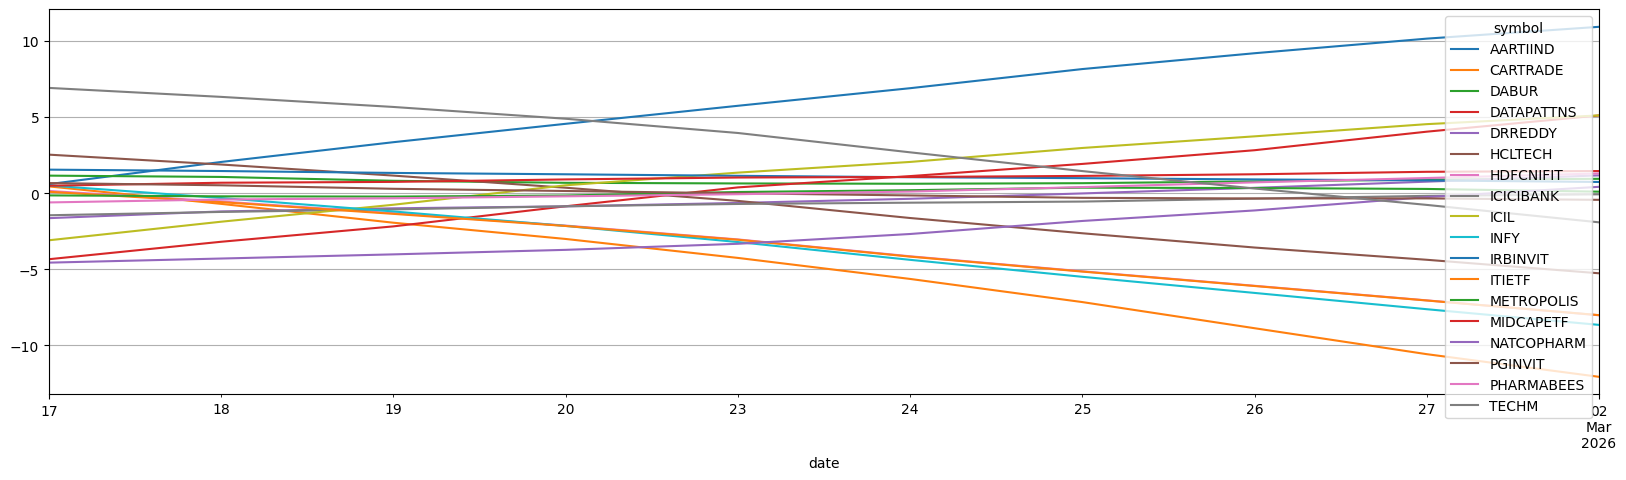

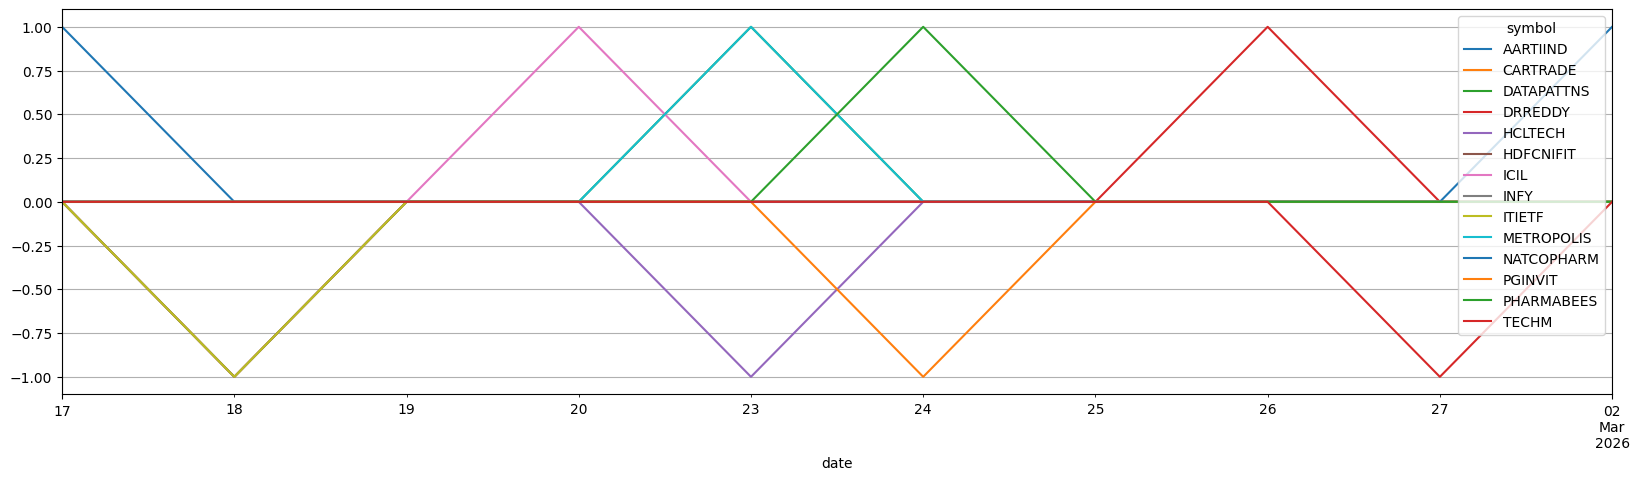

In [26]:
if (ip.shape[0] > 0 ):
    ipfig = ip.T.plot(figsize=(20,5), grid=True).get_figure()
if (sp.shape[0] > 0 ):
    spfig = sp.T.plot(figsize=(20,5), grid=True).get_figure()

In [27]:
i52whp = pvt["52WH_P"].tail(5)
i52wlp = pvt["52WL_P"].tail(5)
i52whlp = pvt["52WHLP"].tail(5)

In [28]:
# stocks staying close to 52WL. 
g52wl = i52wlp.loc[:, i52wlp[(i52wlp < 20) ].any()].T
g52wh = i52whp.loc[:, i52whp[(i52whp > 40.0) ].any()].T
g52wl

date,2026-02-24,2026-02-25,2026-02-26,2026-02-27,2026-03-02
symbol,,,,,
ABBOTINDIA,0.285280,0.456447,0.247242,0.912895,1.958920
ADANIPORTS,27.869122,25.663790,22.373925,16.973006,13.073906
AMBUJACEM,3.448276,2.764653,2.975772,0.613250,0.000000
ARE&M,5.193533,3.882901,4.568839,3.497060,0.986036
ASIANPAINT,9.636529,9.786461,8.809632,7.960018,4.820536
...,...,...,...,...,...
TTKPRESTIG,2.047943,0.226501,0.000000,0.000000,0.000000
WHIRLPOOL,16.858361,18.874386,16.716206,19.132851,18.163608
WIPRO,0.000000,0.889377,0.469671,0.409713,0.000000


In [29]:
# i52whp.T
g52wh

date,2026-02-24,2026-02-25,2026-02-26,2026-02-27,2026-03-02
symbol,,,,,
BAJFINANCE,89.451201,89.476966,89.560445,89.736164,89.918067
BASML,37.353980,37.571312,37.408313,37.516979,41.021462
CAMS,83.479699,83.373710,83.493676,84.215798,84.828438
CARTRADE,45.581395,45.541616,42.897797,44.889841,45.670135
COSMOFIRST,48.420471,44.696730,44.349234,43.820092,45.679987
HDFCAMC,54.490835,53.430075,53.262050,54.198914,55.027155
HDFCBANK,55.054793,55.197946,55.642215,56.177806,56.589989
HGS,37.952935,37.781940,37.032815,38.767201,40.444589
JPPOWER,47.153874,46.088873,46.566287,43.995593,46.860081


DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Users\\PerianayagamThirumal\\AppData\\Roaming\\Python\\Python313\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Users\\PerianayagamThirumal\\AppData\\Roaming\\Python\\Python313\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmtt10.ttf', name='cmtt10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Users\\PerianayagamThirumal\\AppData\\Roaming\\Python\\Python313\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='norma

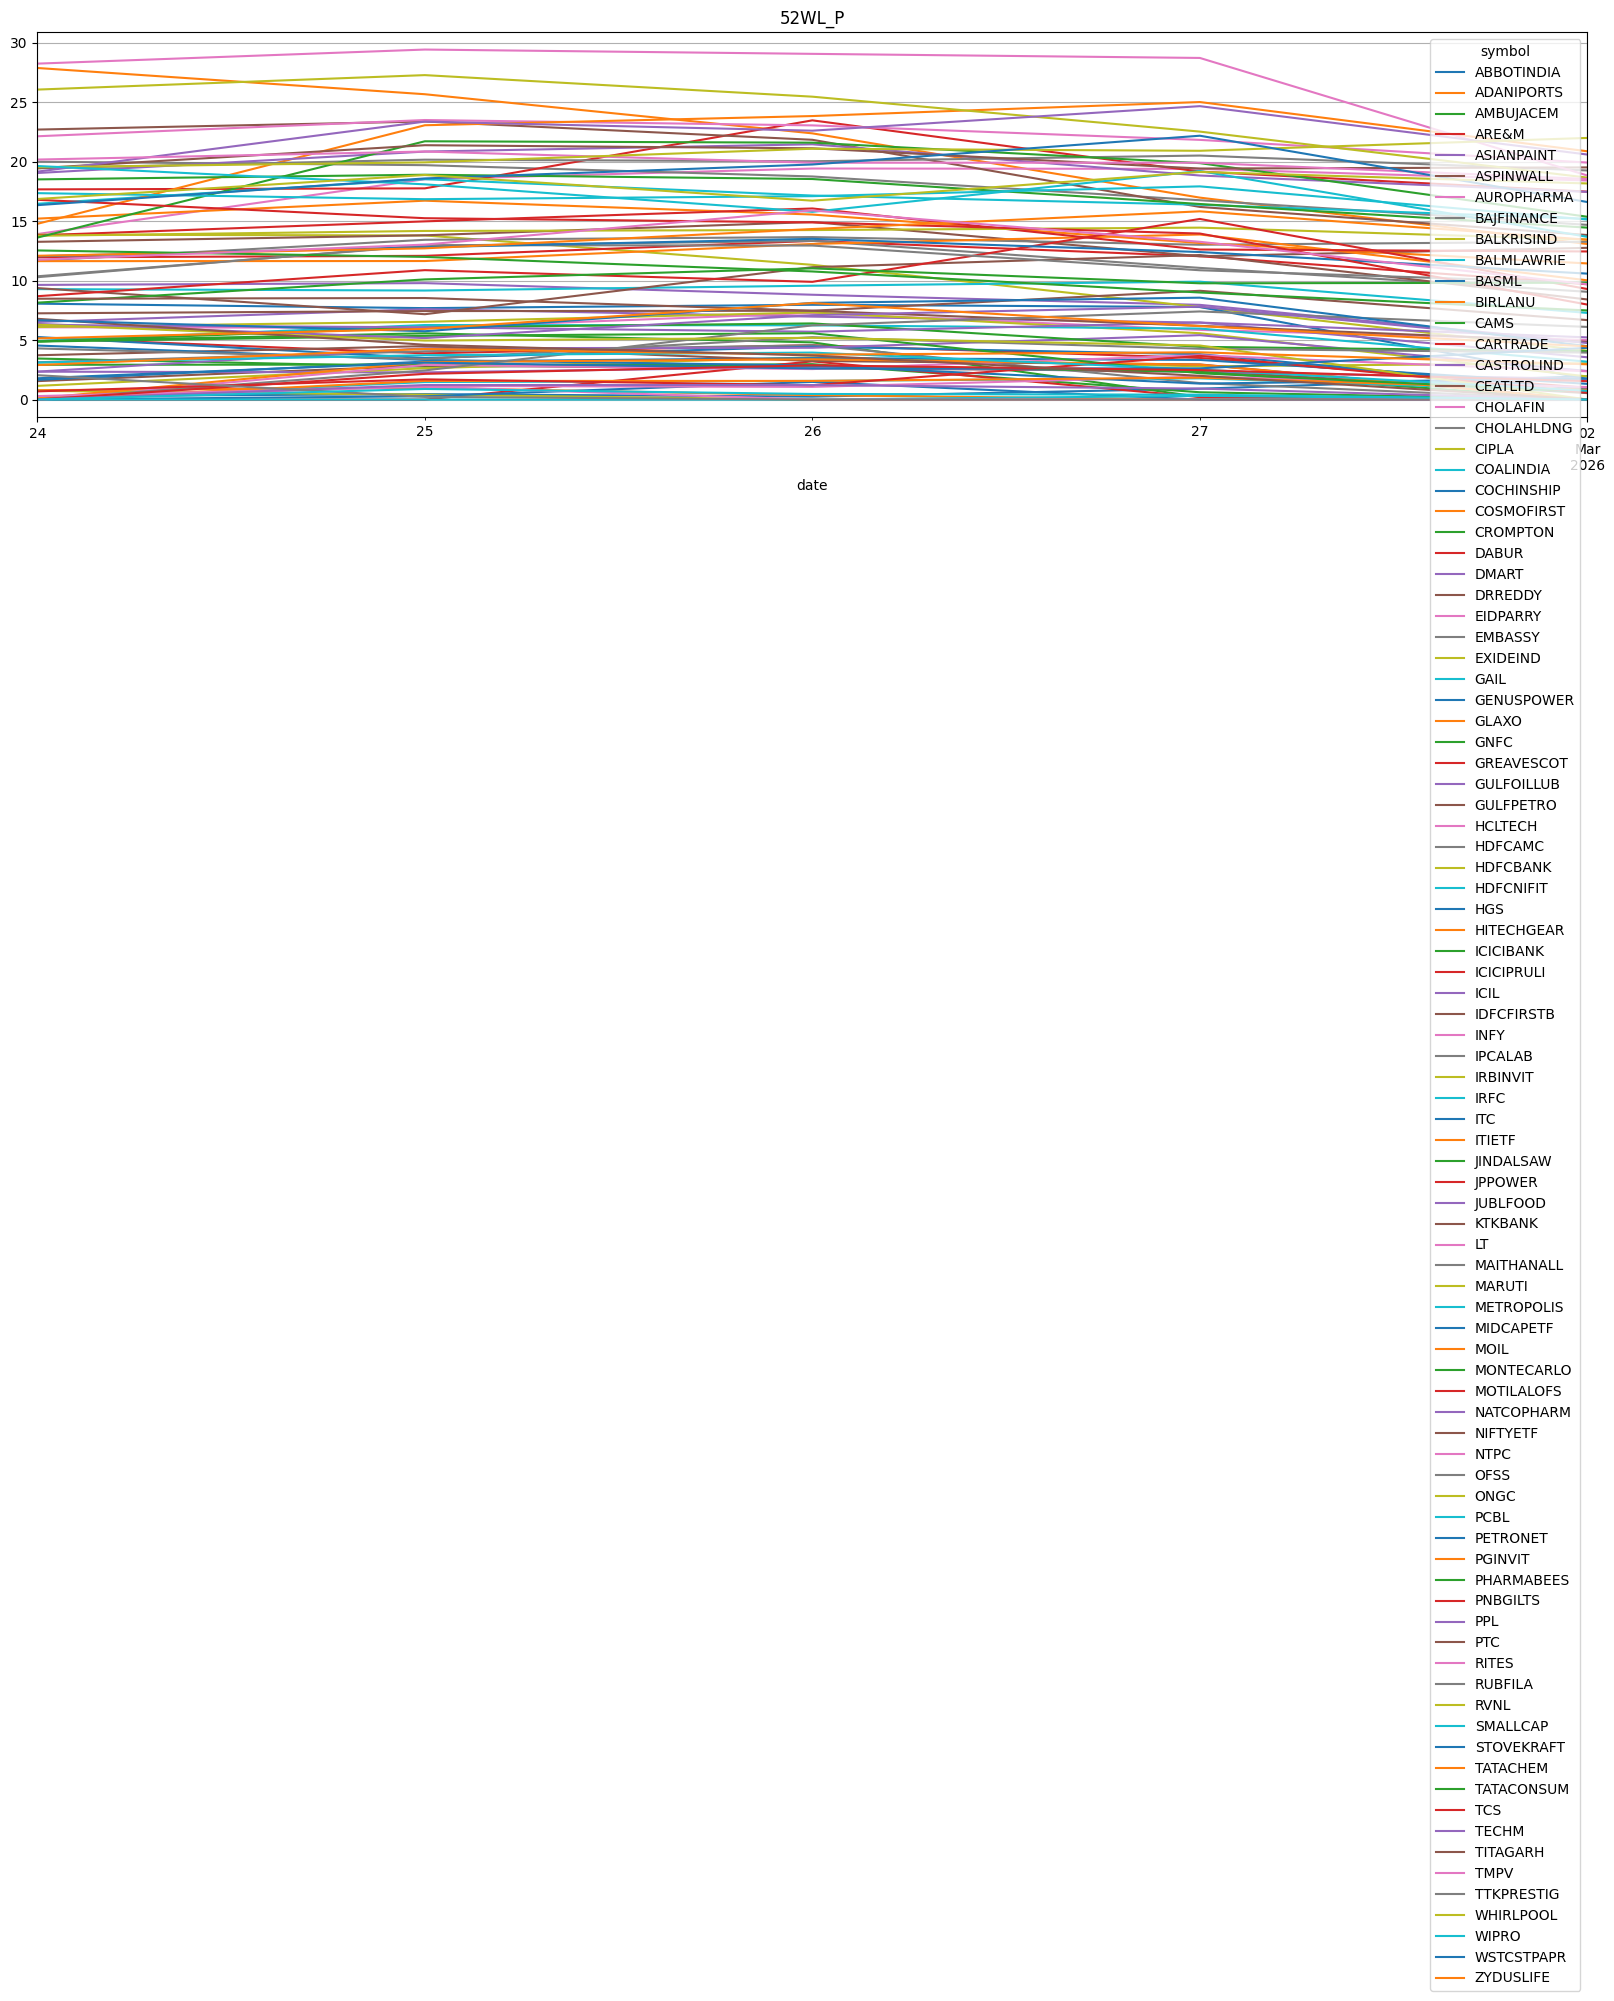

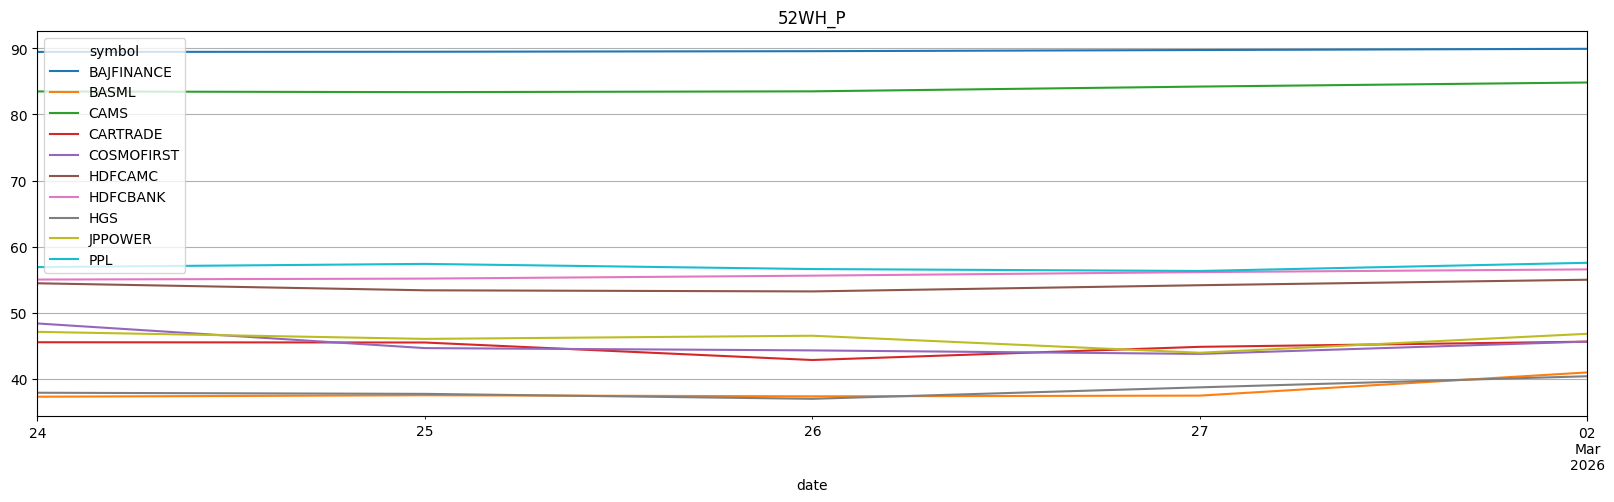

In [30]:
if (g52wl.shape[0] > 0 ):
    g52wl.T.plot(figsize=(20,5), grid=True,title='52WL_P')
if (g52wh.shape[0] > 0 ):
    g52wh.T.plot(figsize=(20,5), grid=True,title='52WH_P')    

In [31]:
# stocks fell a lot from 52WH close to 52WL. 
i52whp.loc[:, i52whp[(i52whp > 10.0) ].any()].T

date,2026-02-24,2026-02-25,2026-02-26,2026-02-27,2026-03-02
symbol,,,,,
AARTIIND,7.591166,6.245506,6.379045,8.135593,11.052902
ABBOTINDIA,26.086347,25.960191,26.114382,25.623773,24.852817
AMBUJACEM,17.089679,17.637580,17.468375,19.361856,20.916929
ARE&M,21.167615,22.149807,21.635763,22.438957,24.320727
ASIANPAINT,18.709786,18.598619,19.322890,19.952838,22.280613
...,...,...,...,...,...
TTKPRESTIG,24.506039,25.853522,26.384137,27.012497,30.021644
WHIRLPOOL,37.439463,36.360177,37.515567,36.221807,36.740695
WIPRO,26.599919,25.947116,26.255180,26.299189,27.175707


In [32]:
ULIM_52WH = 100
LLIM_52WH = 25

i52whlpl_all = i52whlp.tail(1).T
i52whlpl_low = i52whlp.tail(1).loc[:, i52whlp[(i52whlp<LLIM_52WH)].any()].T
i52whlpl_high = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>ULIM_52WH)].any()].T
col = i52whlpl_all.columns.values[0]

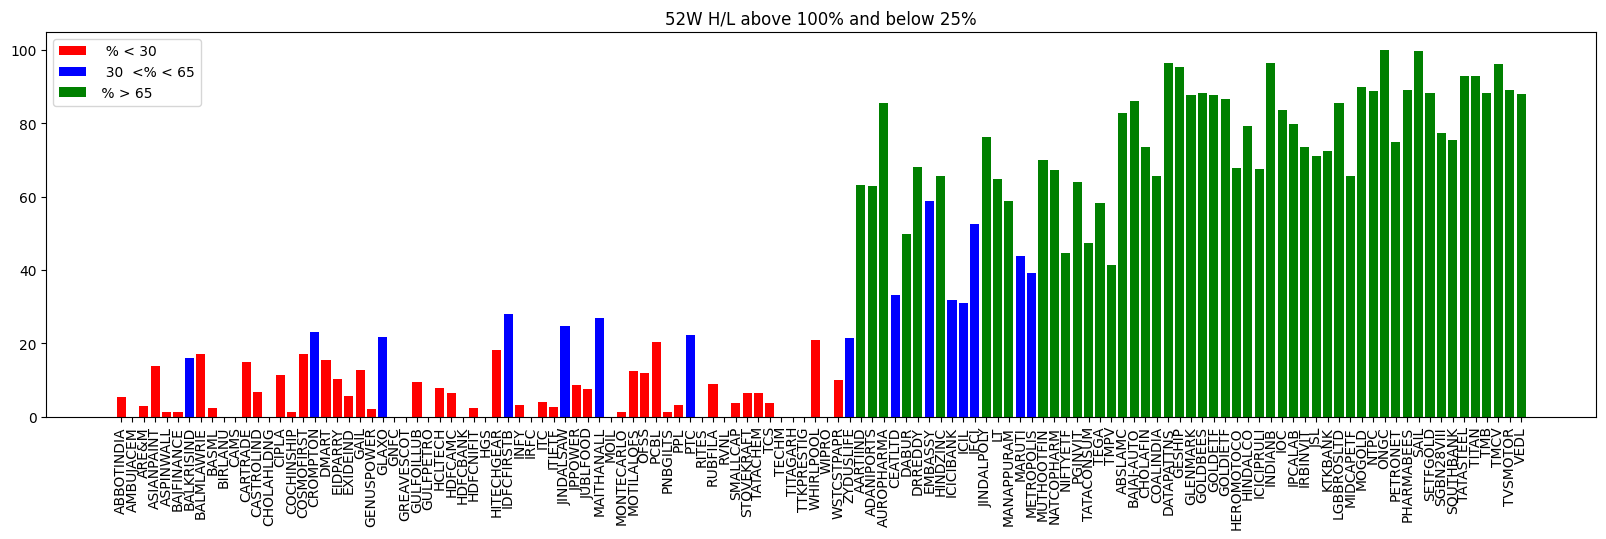

In [33]:
import matplotlib.pyplot as plt
# i52whlpl.plot(kind='bar', figsize=(20,5), grid=True)


plt.figure(figsize=(20,5))
plt.xticks(rotation=90)

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp<=30)].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='red', label="  % < 30")

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>30) & (i52whlp<=65) ].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='blue', label="  30  <% < 65")

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>65) ].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='green',label=" % > 65")

plt.bar(i52whlpl_high.index, i52whlpl_high[col], color='blue')
plt.title("52W H/L above {}% and below {}%".format(ULIM_52WH, LLIM_52WH))
plt.legend()
fig52whlclr = plt
fig52whlclr = getImgData(fig52whlclr)
plt.show()


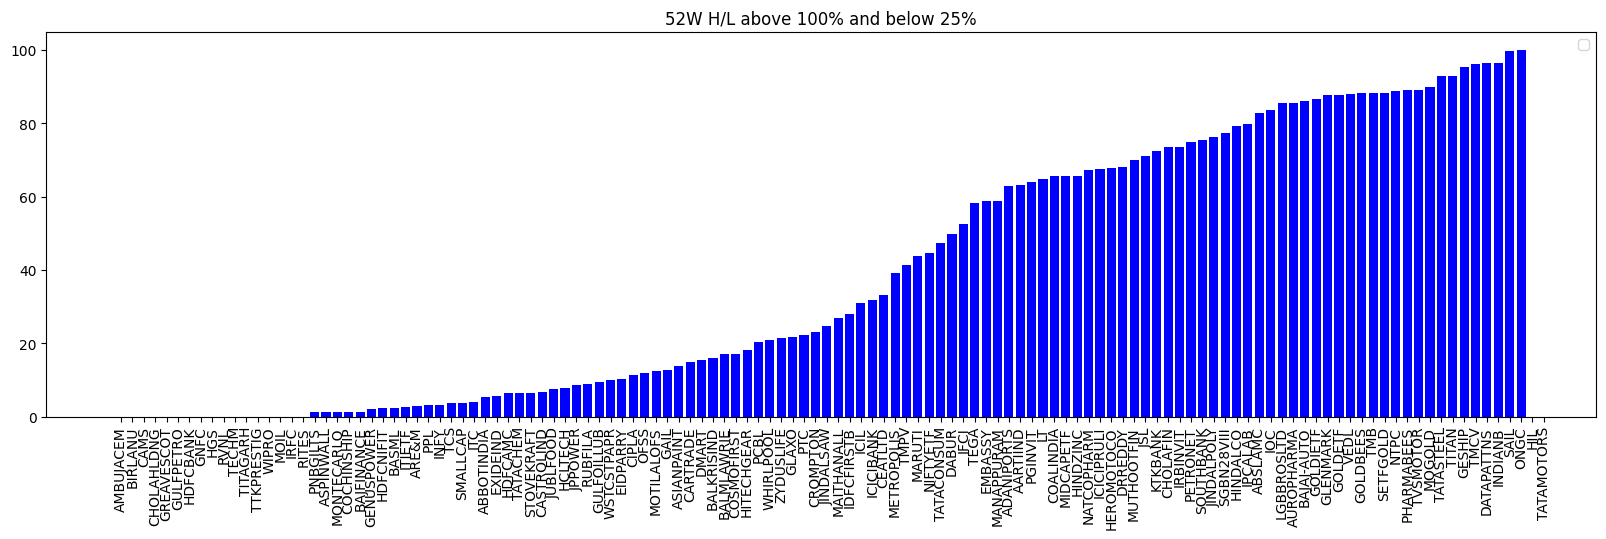

In [34]:
plt.figure(figsize=(20,5))
plt.xticks(rotation=90)

tmp = i52whlp.tail(1)
_t = tmp.T.sort_values(by=tmp.T.columns.values[0])
# _t.plot(kind='bar', figsize=(20,5), grid=True)

plt.bar(_t.index, _t[_t.columns[0]], color='blue', )
plt.title("52W H/L above {}% and below {}%".format(ULIM_52WH, LLIM_52WH))


plt.legend()
fig52whlclr = plt
fig52whlclr = getImgData(fig52whlclr)
plt.show()


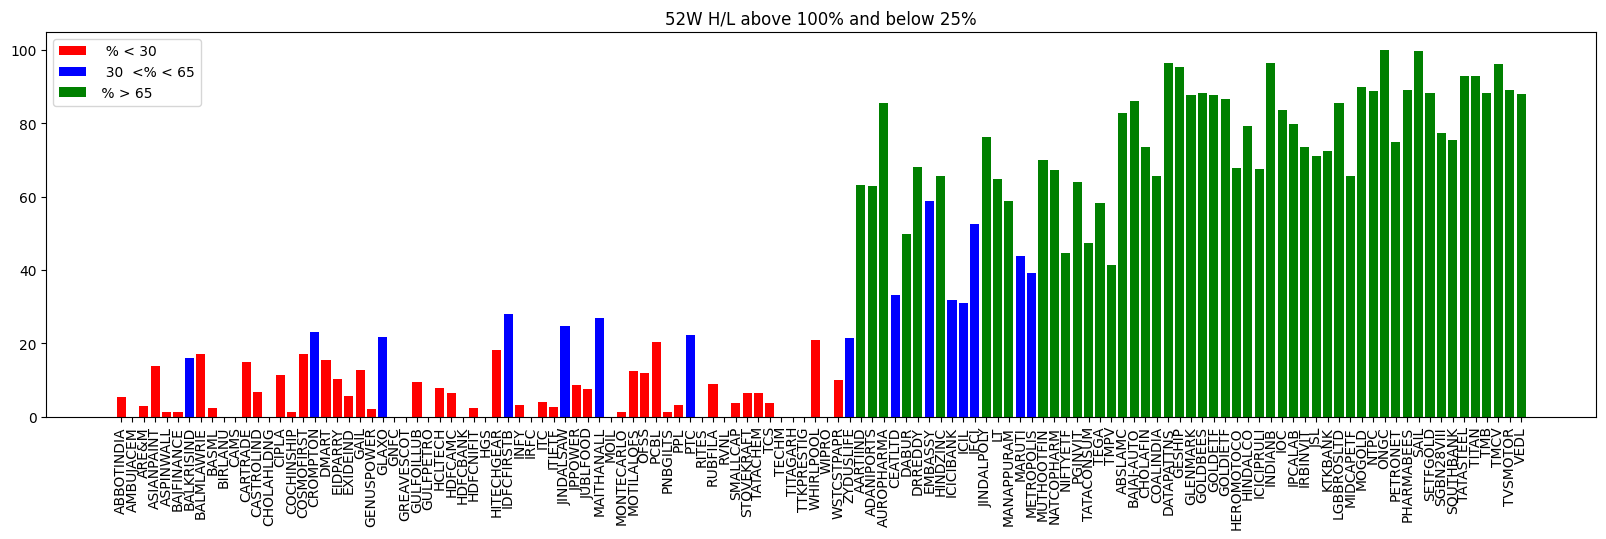

In [35]:
# i52whlpl.plot(kind='bar', figsize=(20,5), grid=True)
plt.figure(figsize=(20,5))
plt.xticks(rotation=90)

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp<=30)].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='red', label="  % < 30")

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>30) & (i52whlp<=65) ].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='blue', label="  30  <% < 65")

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>65) ].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='green',label=" % > 65")

plt.bar(i52whlpl_high.index, i52whlpl_high[col], color='blue')
plt.title("52W H/L above {}% and below {}%".format(ULIM_52WH, LLIM_52WH))
plt.legend()
fig52whlclr = plt
fig52whlclr = getImgData(fig52whlclr)
plt.show()

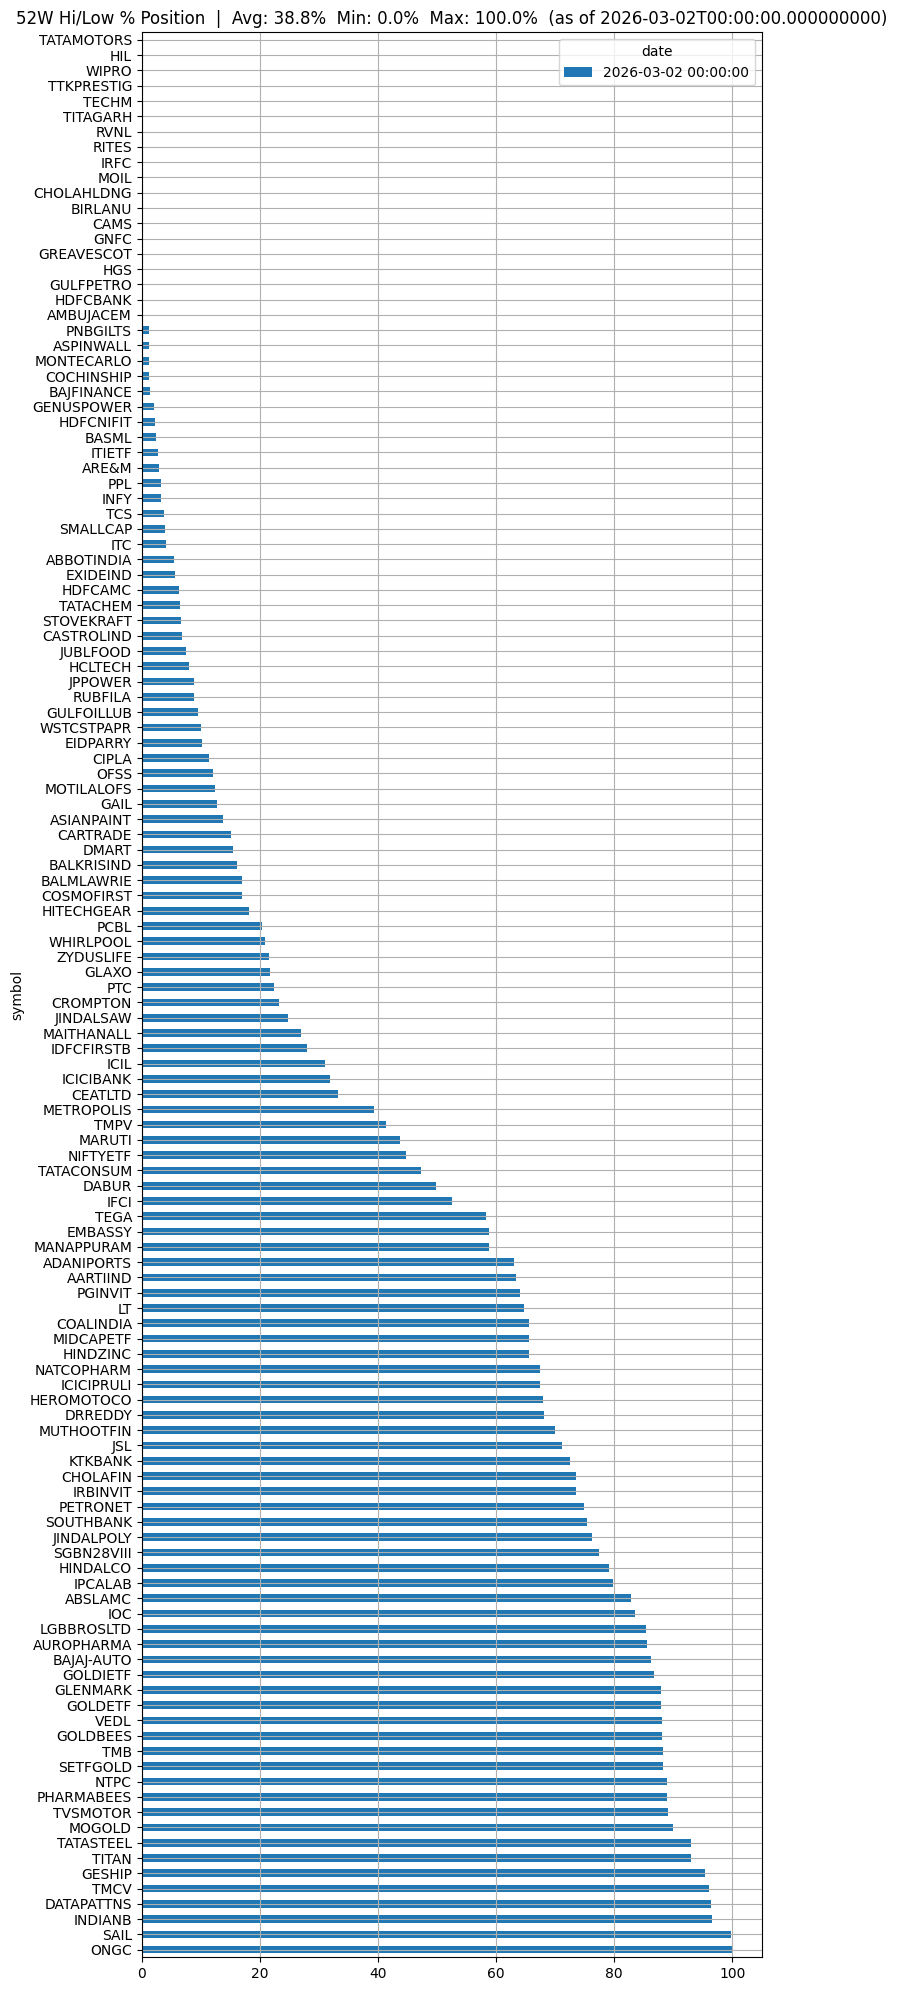

In [36]:
avg_pct = i52whlpl_all[col].mean()
min_pct = i52whlpl_all[col].min()
max_pct = i52whlpl_all[col].max()
chart_title = '52W Hi/Low % Position  |  Avg: {:.1f}%  Min: {:.1f}%  Max: {:.1f}%  (as of {})'.format(avg_pct, min_pct, max_pct, col)
fig52whl = i52whlpl_all.sort_values(by=[col], ascending=False).plot(kind='barh', figsize=(8,25), grid=True, title=chart_title).get_figure()

In [37]:
i52whlpl_allcsv = pd.DataFrame(i52whlpl_all[col])

In [38]:
i52whlpl_allcsv.sort_values(by=[col]).to_csv(MY_PATH+"./dump/STKS-52WHLP-"+n+".csv")

In [39]:
i52whlpl_allcsv.sort_values(by=[col])

,2026-03-02
symbol,
AMBUJACEM,0.000000
BIRLANU,0.000000
CAMS,0.000000
CHOLAHLDNG,0.000000
GREAVESCOT,0.000000
...,...
INDIANB,96.609784
SAIL,99.788360
ONGC,100.000000


In [40]:
t1WHLP, t1MHLP, t3MHLP, t6MHLP, t1YHLP = SA.getProcessedGainerLoser(pvt)

In [41]:
t1mhl, t3mhl, t6mhl, t1yhl = SA.getProcessedByMilestone(pvt)
# t1mhl.size

In [42]:

style_text = """
<meta name="viewport" content="width=device-width, initial-scale=1">
<style>
* {
  box-sizing: border-box;
}

/* Create two equal columns that floats next to each other */
.col {
  float: left;
  width: 50%;
}

/* Clear floats after the columns */
.row:after {
  width: 50%;
}
</style>

"""

## get sorted PEs

In [43]:
pelist = capital_market.pe_ratio(trade_date=datetime.datetime.now().strftime("%d-%m-%Y"))

In [44]:

myPE = pelist[pelist['SYMBOL'].isin(stklist) & (pelist['ADJUSTEDP/E']<100) ].sort_values(by='ADJUSTEDP/E')


In [45]:
myPE['dSymbol'] = myPE['SYMBOL'] + ' (' + myPE['ADJUSTEDP/E'].astype('str') +' )'

In [46]:
myPE.tail(20)

,SYMBOL,SYMBOLP/E,ADJUSTEDP/E,dSymbol
254,AARTIIND,41.59,42.40,AARTIIND (42.4 )
236,GLAXO,42.02,42.66,GLAXO (42.66 )
1344,STOVEKRAFT,43.89,43.89,STOVEKRAFT (43.89 )
209,ICIL,46.25,46.25,ICIL (46.25 )
165,PCBL,44.99,48.23,PCBL (48.23 )
183,DABUR,49.46,49.14,DABUR (49.14 )
328,HITECHGEAR,51.67,51.67,HITECHGEAR (51.67 )
1133,COCHINSHIP,52.42,52.42,COCHINSHIP (52.42 )
1286,METROPOLIS,56.86,54.61,METROPOLIS (54.61 )
73,ASIANPAINT,59.07,55.57,ASIANPAINT (55.57 )


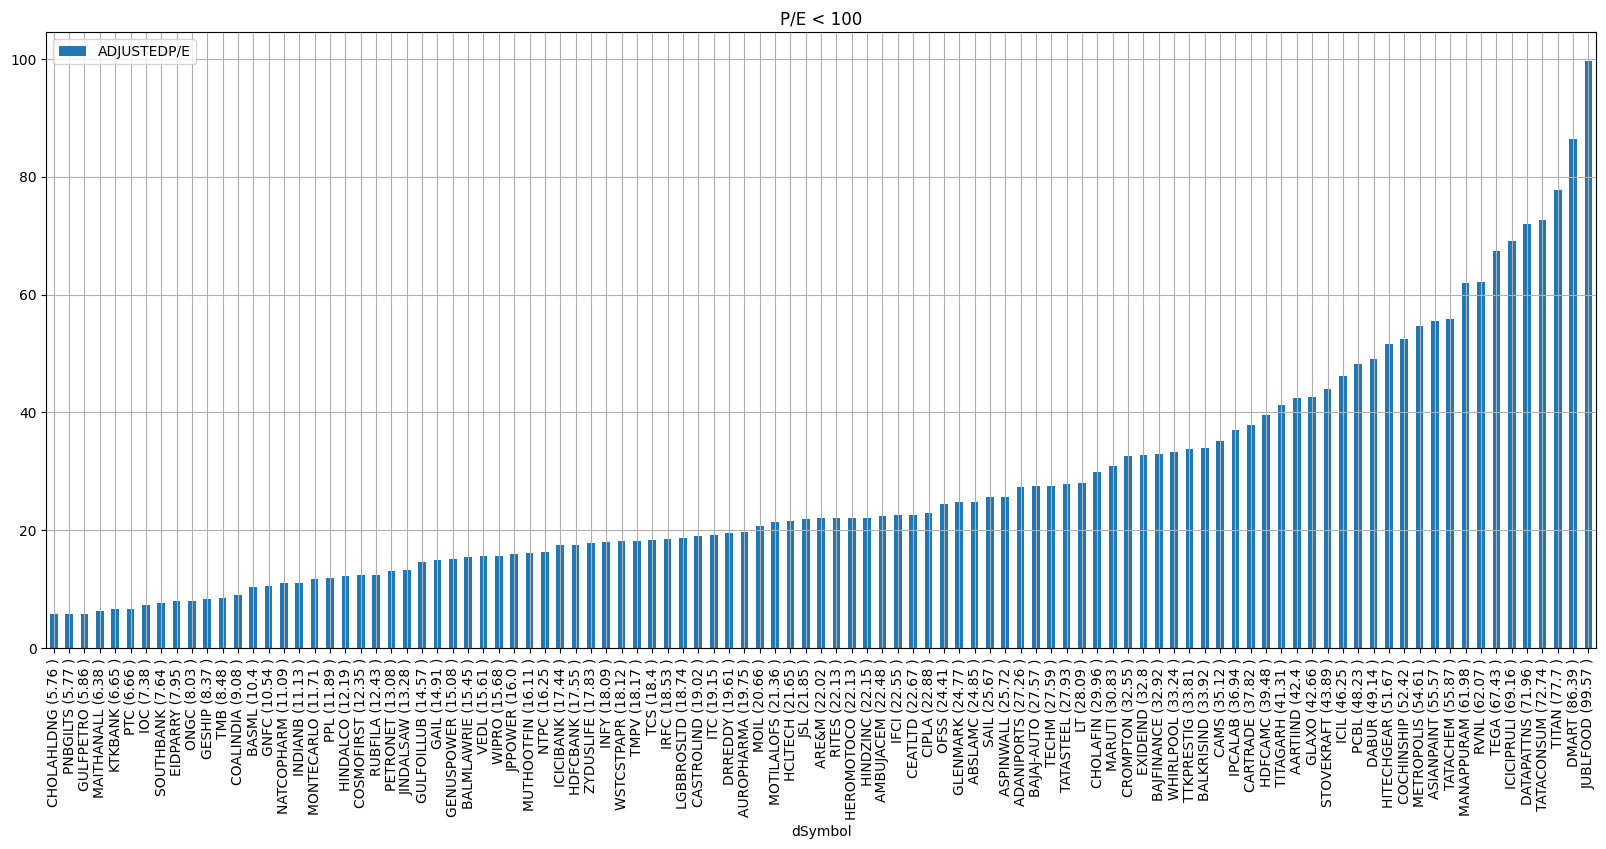

In [47]:
pefig = myPE.plot(kind='bar', x='dSymbol', y='ADJUSTEDP/E', figsize=(20,8), grid=True, title='P/E < 100').get_figure()
pefig = getImgData(pefig)

In [48]:
# top_gainer_losers.sort_values(by=['6md']).head(100)

In [49]:
# top_gainer_losers.to_csv

In [ ]:
# email
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.image import MIMEImage
import os
from base64 import b64encode

me  = 'peri47.study@gmail.com'
recipient = 'peri47.study@gmail.com'
# recipient = ['peri47.study@gmail.com', 'rite2peri@gmail.com', 'peri47.t@gmail.com']
subject = 'Signals for {}'.format('NSE')

email_server_host = 'smtp.gmail.com'
port = 587
email_username = 'peri47.study@gmail.com'
email_password = 'fhih lsqp wanu leic'


msg = MIMEMultipart('alternative')
msg['From'] = me
msg['To'] = recipient
msg['Subject'] = subject
img_format = 'png'


msg.add_header('Content-Type','text/html')
section1 = """\
<html>
    <head> 
    {style_text}
    </head>
    <body>
            <H1>Stocks in Golden X - Signals: </H1>
            {signal_goldenx}
            <H1>Stocks nearing Golden X : </H1>
            {nearing_goldenx}
        <div class="row">
            <div class="col">
                <H1> %  From 52W H/L - Top 10: (Near Low)</H1>
                {hl52w_top10}
            </div>
            <div class="col">
                <H1>% From 52W H/L - Bottom10: (Near High)</H1>
                {hl52w_last10}
            </div>
        </div>
        <section>
            <div class="row">        
                <div class="col">
                    <H1> 1 weekLow </H1>
                    {l1w}
                </div>

                <div class="col">
                    <H1> 1 week Hi </H1>
                    {h1w}
                </div>
            </div>
        </section>
        <section>
            <div class="row">        
                <div class="row">        
                    <H1> 3 month low </H1>
                    {l3m}
                </div>

                <div class="col">
                    <H1> 3 month Hi </H1>
                    {h3m}
                </div>
            </div>
        </section>
        <section>
            <H1> Top Gainers / Losers  </H1>
                    <H1> 1 Week losers </H1>
                    {l1wl}
                    <H1> 1 Week gainers </H1>
                    {l1wh}
            <H1> 1 Month losers </H1>
            {l1ml}
            <H1> 1 Month gainers </H1>
            {l1mh}
            <H1> 3 Month losers </H1>
            {l3ml}
            <H1> 3 Month gainers </H1>
            {l6mh}
            <H1> 6 Month losers </H1>
            {l6ml}
            <H1> 6 Month gainers </H1>
            {l3mh}
        </section>
        <section>
            <H1> PE low to high </H1>
            {PElh}
        </section>        
    </body>
</html>
""".format(nearing_goldenx=ip.to_html(),
           signal_goldenx=sp.to_html(),
           hl52w_top10 = i52whlpl_all.dropna().sort_values(by=[col]).head(10).to_html(), 
           hl52w_last10 = i52whlpl_all.dropna().sort_values(by=[col]).tail(10).to_html(),
           h1w = t1mhl.dropna().tail(10).to_html() , l1w = t1mhl.dropna().head(10).to_html() , h3m = t3mhl.dropna().tail(10).to_html(),
           l3m= t3mhl.dropna().head(10).to_html(),
           l1wl = top_gainer_losers.sort_values(by=['1wd']).head(10).to_html(),
           l1wh = top_gainer_losers.sort_values(by=['1wd']).tail(10).to_html(),
           l1ml = top_gainer_losers.sort_values(by=['1md']).head(10).to_html(),
           l1mh = top_gainer_losers.sort_values(by=['1md']).tail(10).to_html(),
           l3ml = top_gainer_losers.sort_values(by=['3md']).head(10).to_html(),
           l3mh = top_gainer_losers.sort_values(by=['3md']).tail(10).to_html(),
           l6ml = top_gainer_losers.sort_values(by=['6md']).head(10).to_html(),
           l6mh = top_gainer_losers.sort_values(by=['6md']).tail(10).to_html(),
           PElh = myPE.to_html(),
           style_text = style_text,
           date=col )
email_body = section1
# msg.a

msg.attach(MIMEText(section1, 'html'))
# msgimg = 
msg.attach(MIMEImage(getImgData(fig52whl)))
msg.attach(MIMEImage(fig52whlclr))
msg.attach(MIMEImage(pefig))

csvattach = MIMEText(top_gainer_losers.sort_values(by=['6md']).to_csv())
csvattach.add_header("Content-Disposition", "attachment", filename='nse_top_gainer_losers.csv')
msg.attach(csvattach)

# attach signal SMA20_2_200P as csv
csvattach = MIMEText(pvt.SMA20_2_200P.tail(SIGNAL_WINDOW).T.to_csv())
csvattach.add_header("Content-Disposition", "attachment", filename='SMA20_2_200P.csv')
msg.attach(csvattach)





try:
    ipfig
except: 
    #ignore
    print('')
else:
    msg.attach(MIMEImage(getImgData(ipfig)))

try:
    spfig
except: 
    #ignore
    print('')
else:
    msg.attach(MIMEImage(getImgData(spfig)))

# f = open("./test.html", "w")
# f.write(section1)
# f.close()

In [55]:
server = smtplib.SMTP(email_server_host, port)
server.ehlo()
server.starttls()
server.login(email_username, email_password)
server.sendmail(me, recipient, msg.as_string())
server.close()


SMTPAuthenticationError: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials ffacd0b85a97d-439b4e771basm22854725f8f.0 - gsmtp')

In [ ]:
top_gainer_losers

date,2026-01-21 00:00:00,2026-01-20 00:00:00,2026-01-13 00:00:00,2025-12-22 00:00:00,2025-10-24 00:00:00,2025-07-28 00:00:00,2025-01-31 00:00:00,1dd,1wd,1md,3md,6md,12md
symbol,,,,,,,,,,,,,
AARTIIND,340.00,345.75,363.00,374.95,381.70,428.50,444.70,-1.663051,-6.336088,-9.321243,-10.924810,-20.653442,-23.543962
ABBOTINDIA,27575.00,27210.00,28090.00,28010.00,29930.00,32895.00,26173.30,1.341419,-1.833393,-1.553017,-7.868360,-16.172671,5.355458
ABSLAMC,781.95,786.65,821.05,762.30,830.60,870.20,683.10,-0.597470,-4.762195,2.577725,-5.857212,-10.141347,14.470795
ADANIPORTS,1378.60,1367.60,1428.60,1508.70,1429.00,1376.00,1099.35,0.804329,-3.499930,-8.623318,-3.526942,0.188953,25.401374
AMBUJACEM,538.65,536.30,537.65,539.95,555.00,611.05,512.80,0.438188,0.185995,-0.240763,-2.945946,-11.848458,5.040952
...,...,...,...,...,...,...,...,...,...,...,...,...,...
VEDL,676.65,671.80,637.20,585.65,495.60,437.95,441.40,0.721941,6.191149,15.538291,36.531477,54.503939,53.296330
WHIRLPOOL,787.50,784.60,809.65,957.60,1370.60,1379.70,1139.80,0.369615,-2.735750,-17.763158,-42.543412,-42.922374,-30.908931
WIPRO,239.55,239.90,264.20,272.67,242.98,250.05,311.90,-0.145894,-9.330053,-12.146551,-1.411639,-4.199160,-23.196537
